# Importacion de las librerias

In [1]:
from tensorflow.keras.models import Sequential
from PIL import Image
import numpy as np
import os
from tensorflow.keras.models import load_model
import cv2
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
pip show tensorflow

Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras


# Se carga el mejor modelo

In [3]:
model_loaded = load_model('/content/drive/MyDrive/CNN_final_shuffle.keras')

In [5]:
from google.colab import files
files.download('/content/drive/MyDrive/CNN_final_shuffle.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Funcion para predecir

In [ ]:
IMG_H, IMG_W = 224, 224

def predecir(path_img):
    # 1) Carga y muestra la imagen original
    img = Image.open(path_img).convert('RGB')
    plt.imshow(img); plt.axis('off'); plt.show()

    # 2) Redimensiona a 224×224 y pasa a array
    img_resized = img.resize((IMG_W, IMG_H))
    arr = np.array(img_resized)  # uint8 [H,W,3]

    # 3) Calcula Canny
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200).astype(np.float32) / 255.0
    edges = edges[..., np.newaxis]  # [H,W,1]

    rgb_norm = arr.astype(np.float32) / 255.0

    # 5) Concatena canales [H,W,4]
    input_4ch = np.concatenate([rgb_norm, edges], axis=-1)

    batch = np.expand_dims(input_4ch, axis=0)

    # 7) Inferencia
    probs = model_loaded.predict(batch)[0]  # [p_sano, p_dañado]

    # 8) Extrae probabilidades y etiqueta
    p_sano, p_danado = probs
    label = 0 if p_sano > p_danado else 1

    print(f"P(sano)   = {p_sano:.4f}")
    print(f"P(dañado) = {p_danado:.4f}")
    print(f"→ Predicción final: {label}  ({'sano' if label==0 else 'dañado'})")

    return label

# Sanos

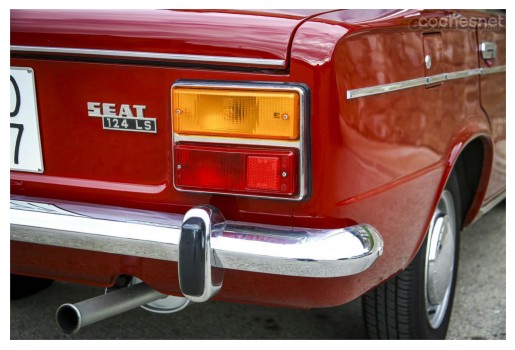

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
P(sano)   = 0.6971
P(dañado) = 0.3029
→ Predicción final: 0  (sano)


0

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/1231383.jpeg')

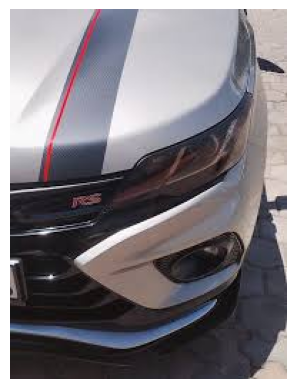

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
P(sano)   = 0.9960
P(dañado) = 0.0040
→ Predicción final: 0  (sano)


0

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/autos_sanos_13.jpeg')

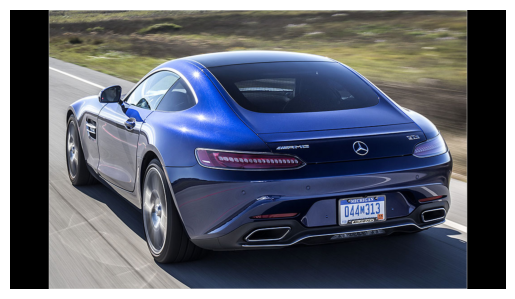

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
P(sano)   = 0.8774
P(dañado) = 0.1226
→ Predicción final: 0  (sano)


0

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/autos_sanos_18.jpg')

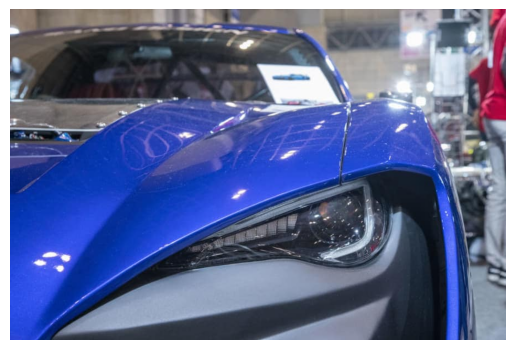

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
P(sano)   = 0.0330
P(dañado) = 0.9670
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/Sano-Design-Bodykit-Toyota-GT86-future-tuning-26.jpeg')

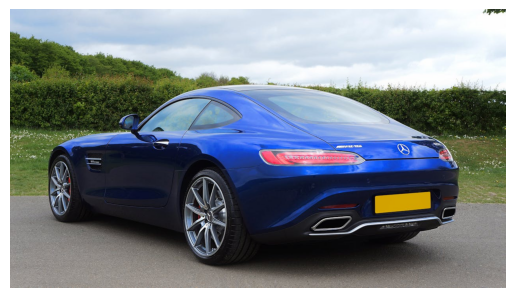

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
P(sano)   = 0.7239
P(dañado) = 0.2761
→ Predicción final: 0  (sano)


0

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/autos_sanos_19.jpeg')

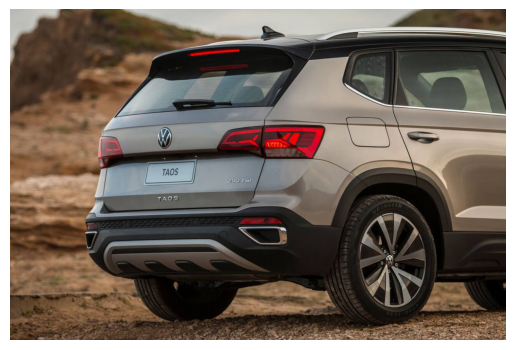

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
P(sano)   = 0.6684
P(dañado) = 0.3316
→ Predicción final: 0  (sano)


0

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/el-volkswagen-taos-uno-de-los-que-incorporo-mas-TBYFUMXXPVB7PP43OR4QNY7VIQ.jpeg')

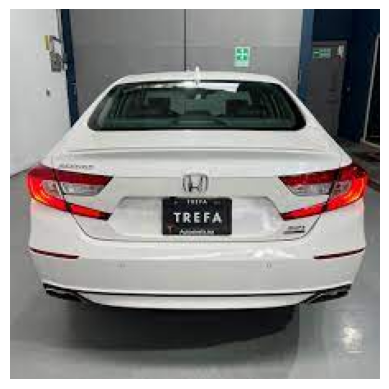

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
P(sano)   = 0.9985
P(dañado) = 0.0015
→ Predicción final: 0  (sano)


0

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/test_auto_3.jpeg')

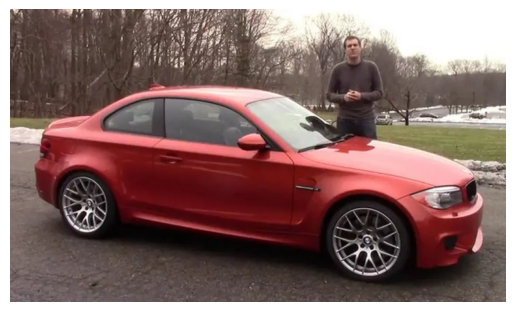

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
P(sano)   = 0.9277
P(dañado) = 0.0723
→ Predicción final: 0  (sano)


0

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/nico10.jpg')

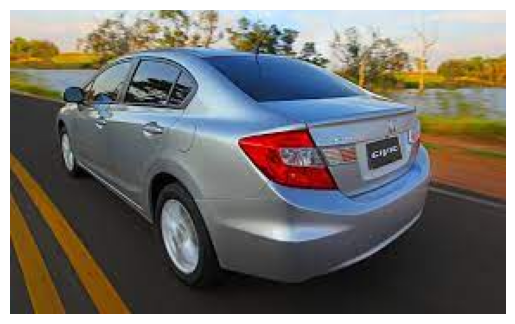

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
P(sano)   = 0.7021
P(dañado) = 0.2979
→ Predicción final: 0  (sano)


0

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/images (3).jpeg')

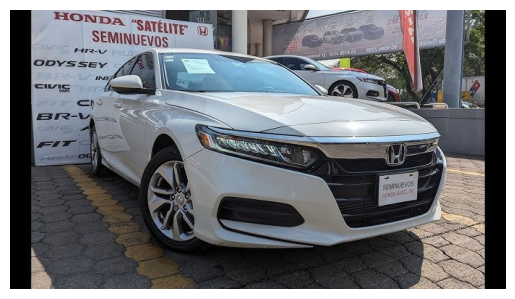

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
P(sano)   = 0.0296
P(dañado) = 0.9704
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_sanos_test/test_auto_4.jpg')

#Dañados

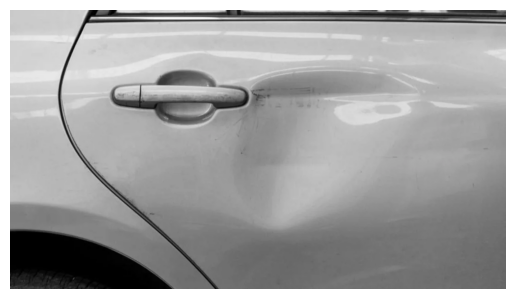

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
P(sano)   = 0.0000
P(dañado) = 1.0000
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/1743179630586.jpeg')

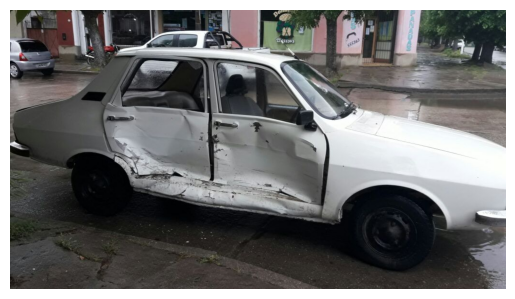

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
P(sano)   = 0.1955
P(dañado) = 0.8045
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/renault-12-chocado.jpeg')

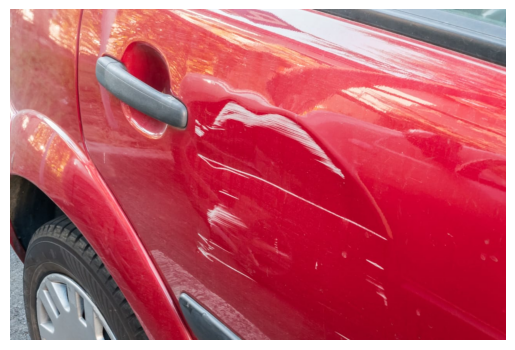

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
P(sano)   = 0.1920
P(dañado) = 0.8080
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/auto_test_1.jpg')

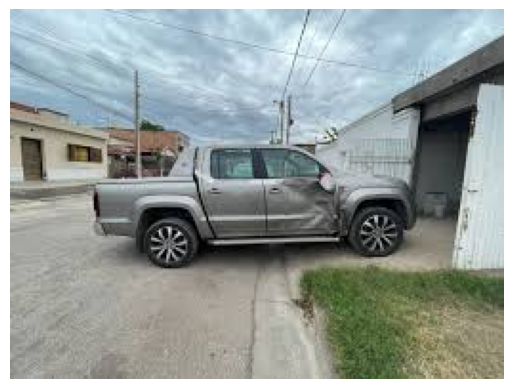

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
P(sano)   = 0.0765
P(dañado) = 0.9235
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/images (2).jpeg')

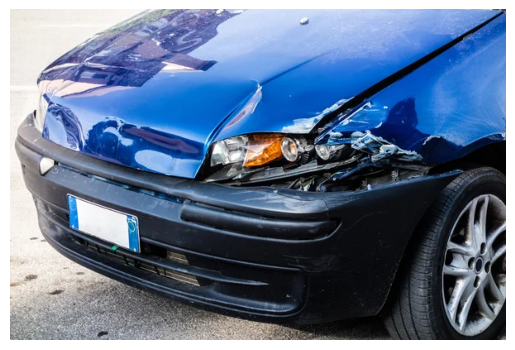

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
P(sano)   = 0.0000
P(dañado) = 1.0000
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/depositphotos_27737371-stock-photo-damaged-car.jpeg')

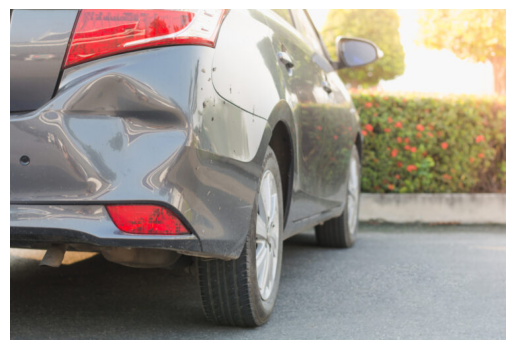

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
P(sano)   = 0.0001
P(dañado) = 0.9999
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/bollo.jpeg')

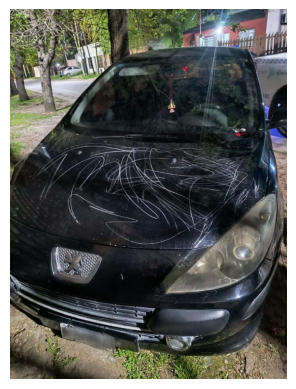

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
P(sano)   = 0.0000
P(dañado) = 1.0000
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/autos_daños_test_2.jpg')

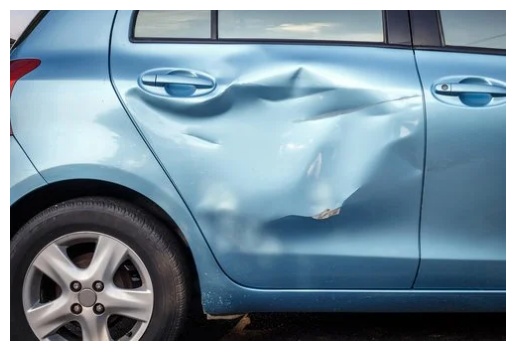

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
P(sano)   = 0.0048
P(dañado) = 0.9952
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/Beule-und-Delle-2.jpeg')

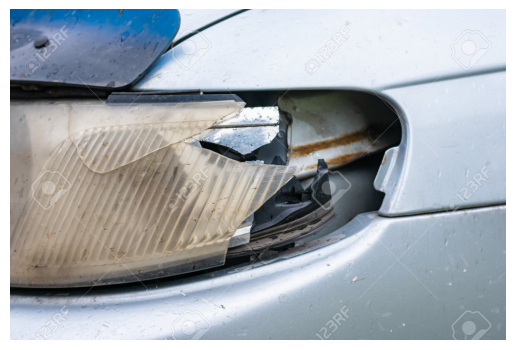

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
P(sano)   = 0.0610
P(dañado) = 0.9390
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/179707547-faro-roto-de-un-automóvil-después-de-una-colisión-menor-debido-a-una-conducción-peligrosa.jpeg')

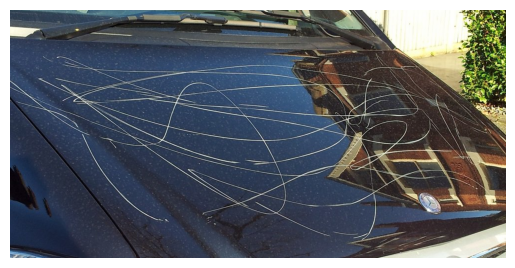

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
P(sano)   = 0.0001
P(dañado) = 0.9999
→ Predicción final: 1  (dañado)


1

In [ ]:
predecir('/content/drive/MyDrive/Autos_daños_test/autos_daños_test_3.jpg')